<a href="https://colab.research.google.com/github/NERTHEN/Chan/blob/main/UTS_DM2_Signal_Clustering_Andrew.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clustering Sinyal Sintetis — Data Mining II
**Andrew Devalent Caunang · 164241085**

Dataset berisi 100.000 sinyal simulasi (128 titik, 128 Hz, 1 detik). Ini bukan rekaman ECG, EEG, suara, atau sensor nyata. Notebook membentuk cluster **tanpa label**, lalu memakai label yang tersedia hanya untuk mengevaluasi hasil pada data uji. Jalankan cell berurutan dan unggah file NPZ saat diminta.

## 1. Unggah dataset dan lihat satu contoh setiap kelas

Saving Data Latihan Datmin II (Signal) to Data Latihan Datmin II (Signal)
File: Data Latihan Datmin II (Signal)
Latih: (80000, 128) | Uji: (20000, 128)
Laju sampling: 128 Hz | Durasi: 1.0 detik
Jumlah per kelas di data uji: [2000 2000 2000 2000 2000 2000 2000 2000 2000 2000]


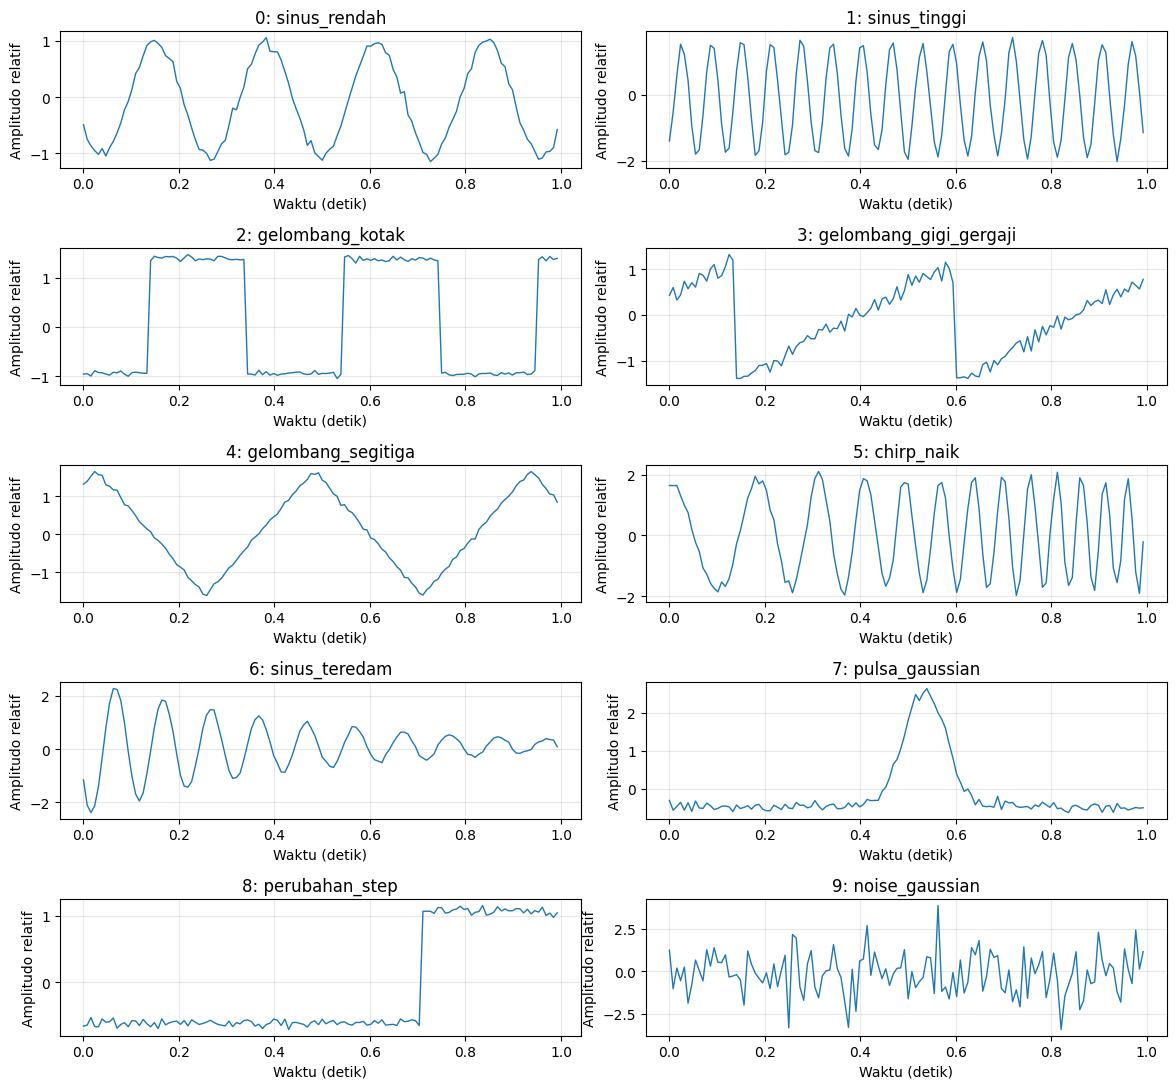

In [1]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
from IPython.display import display
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score,
    adjusted_rand_score, normalized_mutual_info_score
)

uploaded = files.upload()
assert uploaded, "Unggah file Data Latihan Datmin II (Signal)."
filename, payload = next(iter(uploaded.items()))
with np.load(io.BytesIO(payload), allow_pickle=False) as data:
    x_train = data["x_train"].astype("float32")
    y_train = data["y_train"]
    x_test = data["x_test"].astype("float32")
    y_test = data["y_test"]
    class_names = data["class_names"]
    t = data["time_seconds"]
    sample_rate = int(data["sample_rate_hz"].item())

assert x_train.shape == (80000, 128) and x_test.shape == (20000, 128)
print("File:", filename)
print("Latih:", x_train.shape, "| Uji:", x_test.shape)
print("Laju sampling:", sample_rate, "Hz | Durasi:", len(t)/sample_rate, "detik")
print("Jumlah per kelas di data uji:", np.bincount(y_test))

fig, axes = plt.subplots(5, 2, figsize=(12, 11))
for c, ax in enumerate(axes.ravel()):
    idx = np.flatnonzero(y_train == c)[0]
    ax.plot(t, x_train[idx], lw=1)
    ax.set_title(f"{c}: {class_names[c]}")
    ax.set(xlabel="Waktu (detik)", ylabel="Amplitudo relatif")
    ax.grid(alpha=.3)
plt.tight_layout()
plt.show()

## 2. Ekstraksi fitur sinyal
Hitung magnitudo FFT (1–64 Hz), energi, frekuensi dominan, pusat spektrum, entropi, zero crossing, perubahan antar titik, energi awal/akhir, skewness, dan kurtosis. Label kelas tidak dipakai sebagai fitur. Magnitudo FFT membantu mengenali frekuensi walau fase sinyal berubah.

In [2]:
def ekstrak_fitur(x):
    x = x - x.mean(axis=1, keepdims=True)
    rms = np.sqrt(np.mean(x*x, axis=1))
    spektrum = np.abs(np.fft.rfft(x, axis=1)).astype("float32")[:, 1:65]
    daya = spektrum**2
    daya_norm = daya / (daya.sum(axis=1, keepdims=True) + 1e-8)
    frekuensi = np.arange(1, 65, dtype="float32")
    pusat = daya_norm @ frekuensi
    dominan = frekuensi[np.argmax(daya, axis=1)]
    entropi = -(daya_norm * np.log(daya_norm + 1e-12)).sum(axis=1)
    zero_crossing = np.mean(np.diff(np.signbit(x), axis=1), axis=1)
    perubahan = np.mean(np.abs(np.diff(x, axis=1)), axis=1)
    energi_rendah = daya_norm[:, :10].sum(axis=1)
    energi_tinggi = daya_norm[:, 10:].sum(axis=1)
    energi_awal = np.mean(x[:, :32]**2, axis=1)
    energi_akhir = np.mean(x[:, -32:]**2, axis=1)
    statistik = np.column_stack([
        rms, pusat, dominan, entropi, zero_crossing,
        perubahan, energi_rendah, energi_tinggi,
        energi_awal, energi_akhir,
        skew(x, axis=1), kurtosis(x, axis=1)
    ]).astype("float32")
    return np.column_stack([np.log1p(spektrum), statistik]).astype("float32")

F_train = ekstrak_fitur(x_train)
F_test = ekstrak_fitur(x_test)
scaler = StandardScaler()
F_train = scaler.fit_transform(F_train)
F_test = scaler.transform(F_test)
pca = PCA(n_components=30, svd_solver="randomized", random_state=42)
Z_train = pca.fit_transform(F_train)
Z_test = pca.transform(F_test)
print("Fitur awal:", F_train.shape[1], "| Komponen PCA:", Z_train.shape[1])
print("Variasi terjelaskan PCA:", f"{pca.explained_variance_ratio_.sum():.2%}")

Fitur awal: 76 | Komponen PCA: 30
Variasi terjelaskan PCA: 86.92%


## 3. Pilih K pada data latih
Silhouette dan Davies–Bouldin dihitung dari sampel acak 3.000 sinyal latih. Model dilatih pada seluruh 80.000 sinyal latih. Data uji belum dipakai untuk memilih K.

,K,Silhouette latih,Davies-Bouldin latih,Inertia latih
0,8,0.2590,1.3871,1483691.250
1,10,0.2181,1.6749,1400872.125
2,12,0.2179,1.4663,1322754.625


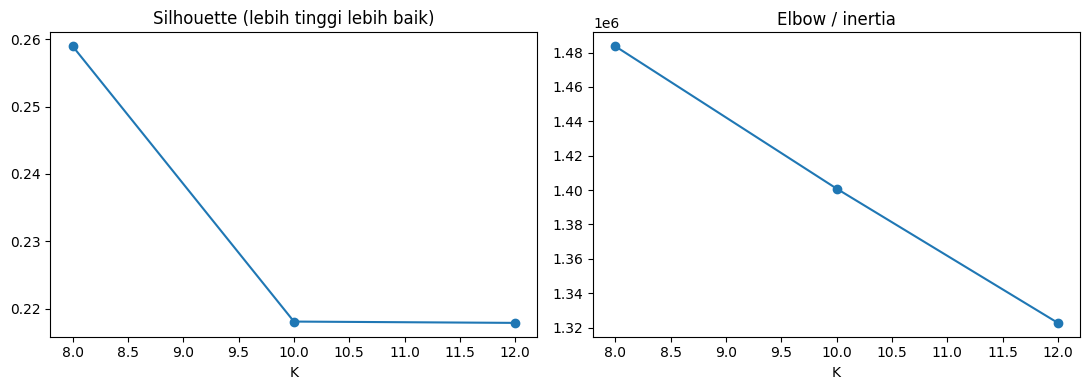

Jumlah cluster terpilih: 8


In [3]:
rng = np.random.default_rng(42)
idx_train = rng.choice(len(Z_train), 3000, replace=False)
models, scores = {}, []
for k in (8, 10, 12):
    model = MiniBatchKMeans(n_clusters=k, random_state=42,
                            batch_size=2048, n_init=3, max_iter=100)
    model.fit(Z_train)
    pred_sampel = model.predict(Z_train[idx_train])
    scores.append({
        "K": k,
        "Silhouette latih": silhouette_score(Z_train[idx_train], pred_sampel),
        "Davies-Bouldin latih": davies_bouldin_score(Z_train[idx_train], pred_sampel),
        "Inertia latih": model.inertia_
    })
    models[k] = model

metrics = pd.DataFrame(scores)
display(metrics.round(4))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(metrics["K"], metrics["Silhouette latih"], "o-")
axes[0].set(title="Silhouette (lebih tinggi lebih baik)", xlabel="K")
axes[1].plot(metrics["K"], metrics["Inertia latih"], "o-")
axes[1].set(title="Elbow / inertia", xlabel="K")
plt.tight_layout()
plt.show()
best_k = int(metrics.loc[metrics["Silhouette latih"].idxmax(), "K"])
model = models[best_k]
print("Jumlah cluster terpilih:", best_k)

## 4. Evaluasi pada 20.000 sinyal uji
Label sebenarnya baru dibaca setelah cluster ditetapkan. ARI dan NMI mengukur kesesuaian cluster dengan kelas generator sinyal; keduanya bukan bagian pelatihan.

ARI uji: 0.6388
NMI uji: 0.7923


cluster,0,1,2,3,4,5,6,7
sinus_rendah,31,656,0,0,0,1313,0,0
sinus_tinggi,1,0,0,31,0,8,1960,0
gelombang_kotak,1134,842,0,0,0,24,0,0
gelombang_gigi_gergaji,1886,105,0,0,0,9,0,0
gelombang_segitiga,40,732,0,0,0,1228,0,0
chirp_naik,0,0,0,2000,0,0,0,0
sinus_teredam,0,76,0,0,7,175,0,1742
pulsa_gaussian,0,0,0,0,2000,0,0,0
perubahan_step,16,1959,0,0,0,19,0,6
noise_gaussian,0,0,2000,0,0,0,0,0


,cluster,jumlah,pola_dominan,proporsi_dominan,pola_kedua
0,0,3108,gelombang_gigi_gergaji,0.607,gelombang_kotak
1,1,4370,perubahan_step,0.448,gelombang_kotak
2,2,2000,noise_gaussian,1.000,sinus_rendah
3,3,2031,chirp_naik,0.985,sinus_tinggi
4,4,2007,pulsa_gaussian,0.997,sinus_teredam
5,5,2776,sinus_rendah,0.473,gelombang_segitiga
6,6,1960,sinus_tinggi,1.000,sinus_rendah
7,7,1748,sinus_teredam,0.997,perubahan_step


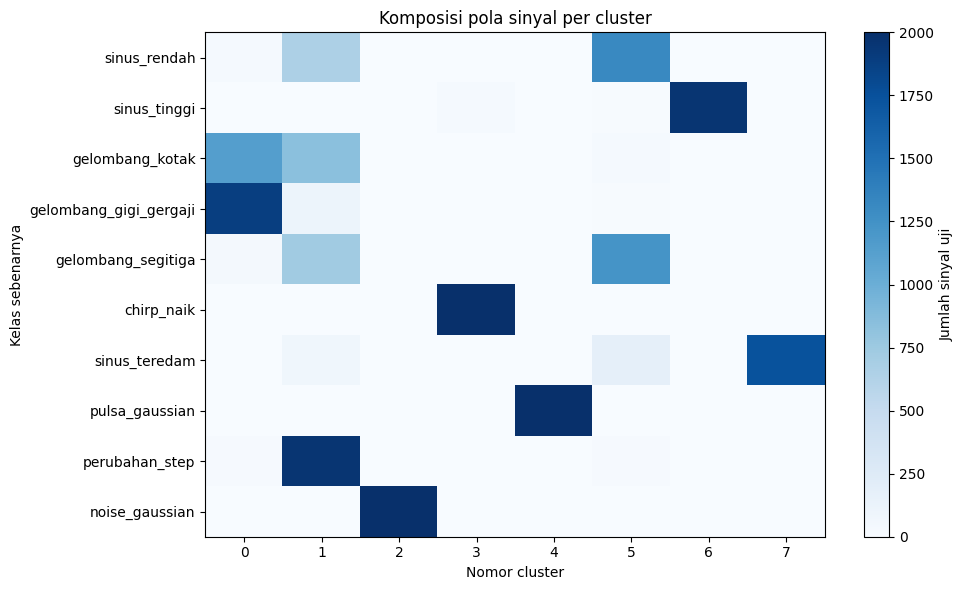

In [4]:
cluster_test = model.predict(Z_test)
print("ARI uji:", round(adjusted_rand_score(y_test, cluster_test), 4))
print("NMI uji:", round(normalized_mutual_info_score(y_test, cluster_test), 4))

komposisi = pd.crosstab(
    pd.Series(y_test, name="kelas_asli"),
    pd.Series(cluster_test, name="cluster")
).reindex(index=range(len(class_names)), columns=range(best_k), fill_value=0)
komposisi.index = [str(nama) for nama in class_names]
display(komposisi)

ringkasan = []
for c in range(best_k):
    urut = komposisi[c].sort_values(ascending=False)
    total = int(urut.sum())
    ringkasan.append({
        "cluster": c, "jumlah": total,
        "pola_dominan": str(urut.index[0]),
        "proporsi_dominan": float(urut.iloc[0]/total),
        "pola_kedua": str(urut.index[1])
    })
ringkasan = pd.DataFrame(ringkasan)
display(ringkasan.round(3))

plt.figure(figsize=(10, 6))
plt.imshow(komposisi.values, cmap="Blues", aspect="auto")
plt.colorbar(label="Jumlah sinyal uji")
plt.xticks(range(best_k), range(best_k))
plt.yticks(range(len(class_names)), class_names)
plt.xlabel("Nomor cluster")
plt.ylabel("Kelas sebenarnya")
plt.title("Komposisi pola sinyal per cluster")
plt.tight_layout()
plt.show()

## 5. Contoh sinyal tiap cluster
Periksa bentuk tiap kelompok. Kelas pada judul dipakai sebagai penjelas setelah clustering; jangan menyamakan nomor cluster dengan nomor kelas.

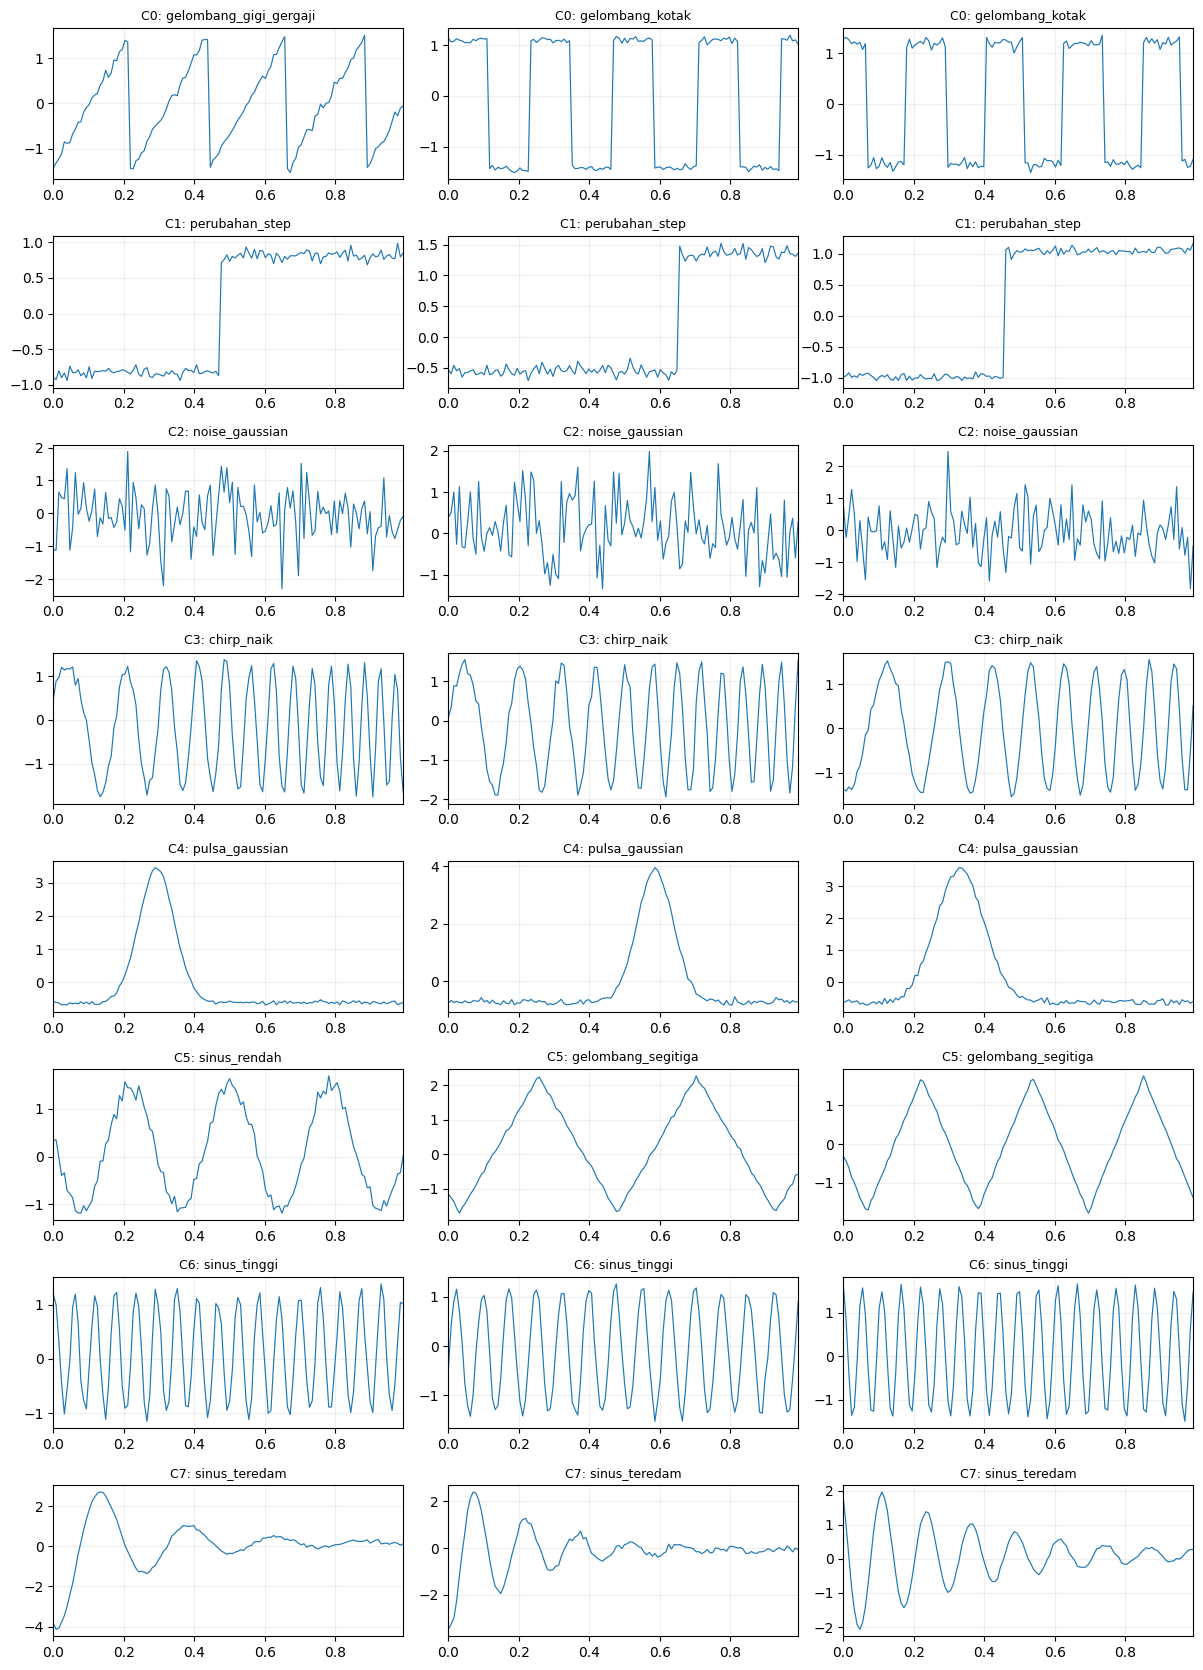

Cluster 0: 3108 sinyal; paling banyak gelombang_gigi_gergaji (60.7%), diikuti gelombang_kotak.
Cluster 1: 4370 sinyal; paling banyak perubahan_step (44.8%), diikuti gelombang_kotak.
Cluster 2: 2000 sinyal; paling banyak noise_gaussian (100.0%), diikuti sinus_rendah.
Cluster 3: 2031 sinyal; paling banyak chirp_naik (98.5%), diikuti sinus_tinggi.
Cluster 4: 2007 sinyal; paling banyak pulsa_gaussian (99.7%), diikuti sinus_teredam.
Cluster 5: 2776 sinyal; paling banyak sinus_rendah (47.3%), diikuti gelombang_segitiga.
Cluster 6: 1960 sinyal; paling banyak sinus_tinggi (100.0%), diikuti sinus_rendah.
Cluster 7: 1748 sinyal; paling banyak sinus_teredam (99.7%), diikuti perubahan_step.


In [5]:
fig, axes = plt.subplots(best_k, 3, figsize=(12, 2.1*best_k))
for c in range(best_k):
    anggota = np.flatnonzero(cluster_test == c)
    contoh = rng.choice(anggota, size=3, replace=False)
    for j, idx in enumerate(contoh):
        ax = axes[c, j]
        ax.plot(t, x_test[idx], lw=.85)
        ax.set_title(f"C{c}: {class_names[y_test[idx]]}", fontsize=9)
        ax.set_xlim(t[0], t[-1])
        ax.grid(alpha=.2)
plt.tight_layout()
plt.show()

for row in ringkasan.itertuples(index=False):
    print(f"Cluster {row.cluster}: {row.jumlah} sinyal; "
          f"paling banyak {row.pola_dominan} ({row.proporsi_dominan:.1%}), "
          f"diikuti {row.pola_kedua}.")

## 6. Proyeksi dan simpan hasil
Proyeksi PCA dua dimensi membantu visualisasi, tetapi jarak dan tumpang tindih pada plot tidak sepenuhnya mewakili 30 dimensi yang dipakai clustering.

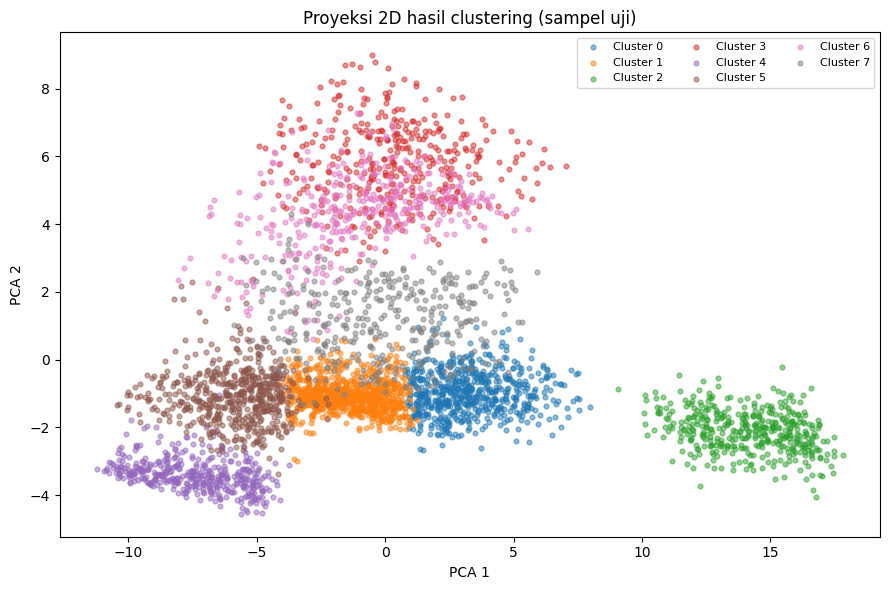

CSV hasil dan ringkasan tersimpan. Untuk laporan, jelaskan cluster campuran dan bahwa semua sinyal berasal dari simulasi matematis.


In [6]:
plot_idx = rng.choice(len(Z_test), 4000, replace=False)
xy = PCA(n_components=2, random_state=42).fit_transform(Z_test[plot_idx])
plt.figure(figsize=(9, 6))
for c in range(best_k):
    mask = cluster_test[plot_idx] == c
    plt.scatter(xy[mask,0], xy[mask,1], s=12, alpha=.5, label=f"Cluster {c}")
plt.title("Proyeksi 2D hasil clustering (sampel uji)")
plt.xlabel("PCA 1"); plt.ylabel("PCA 2")
plt.legend(ncol=3, fontsize=8)
plt.tight_layout(); plt.show()

pd.DataFrame({"kelas_asli":y_test, "cluster":cluster_test}).to_csv(
    "hasil_cluster_signal_uji.csv", index=False)
ringkasan.to_csv("ringkasan_cluster_signal.csv", index=False)
metrics.to_csv("metrik_cluster_signal.csv", index=False)
print("CSV hasil dan ringkasan tersimpan. Untuk laporan, jelaskan cluster campuran "
      "dan bahwa semua sinyal berasal dari simulasi matematis.")
# Untuk unduh salah satu file: files.download("ringkasan_cluster_signal.csv")